# Проект: Недвижимость Бостона. Предсказание цен на жилье.

## Описание проекта:  
Сделать анализ имеющихся данных, разработать модель машинного обучения, для анализа рынка недвижимости.

## План проекта:
  1. Загрузка данных и просмотр данных.
  2. Исследовательский анализ данных.
  3. Подготовка к моделированию.
  4. Создание модели МО
  5. Вывод

## Описание данных:

**Столбец	Полное название	Что означает**
- **CRIM**	Crime rate	Уровень преступности на душу населения
- **ZN**	Zoning	Доля земли под жилую застройку (>25 тыс. футов²)
- **INDUS**	Industry	Доля нежилой площади в городе
- **CHAS**	Charles River	1 — рядом река, 0 — нет
- **NOX**	Nitric oxide	Концентрация оксидов азота (загрязнение)
- **RM**	Rooms	Среднее количество комнат в доме
- **AGE**	Age	Доля домов старше 1940 года
- **DIS**	Distance	Расстояние до 5 центров занятости
- **RAD**	Highway access	Индекс доступности к шоссе
- **TAX**	Tax	Налог на недвижимость
- **PTRATIO**	Pupil-teacher ratio	Соотношение учеников к учителям в школах
- **B**	Black	1000×(Bk — 0.63)² (доля чернокожего населения)
- **LSTAT**	Lower status	Доля населения с низким статусом
- **MEDV**	Target	Медианная цена дома (в тысячах долларов) — это то, что предсказываем

### 1. Загрузка и просмотр данных

Для начала импортируем библиотеки, загрузим файл, сделаем первичный осмотр.

In [61]:
# загрузка библиотек

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

In [7]:
# загрузка дата фрейма

boston = fetch_openml('boston', version = 1, as_frame = True)
data = boston.frame

In [9]:
# размерность

print(f'Размер датафрейма: {data.shape}')

Размер датафрейма: (506, 14)


In [10]:
# инфо

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 49.0 KB


In [11]:
# первые строки

display(data.head())

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


Имеем датафрейм, на 506 строк и 14 столбцов. Типы данных в порядке, но CHAS - позже переведем в int. Далее посмотрим пропуски и дубликаты.

In [15]:
# пропуски и дубликаты

print(f'Пропуски:\n{data.isna().sum()}')
print(f'Дубликаты: {data.duplicated().sum()}')

Пропуски:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64
Дубликаты: 0


Пропуски и дубликаты - отсутствуют.

In [19]:
# проверим уникальные значения CHAS и RAD

print(data['CHAS'].unique())
print(data['RAD'].unique())

['0', '1']
Categories (2, object): ['0', '1']
['1', '2', '3', '5', '4', '8', '6', '7', '24']
Categories (9, object): ['1', '2', '24', '3', ..., '5', '6', '7', '8']


In [20]:
# преобразуем CHAS и RAD в int

data['CHAS'] = data['CHAS'].astype(int)
data['RAD'] = data['RAD'].astype(int)

In [23]:
# проверка

print(f'CHAS: {data["CHAS"].dtype}')
print(f'RAD: {data["RAD"].dtype}')

CHAS: int64
RAD: int64


### 2. Исследовательский анализ данных

Для начала проведем статистический анализ данных.

In [24]:
# статистический анализ

display(data.describe())

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


Предположительно есть выбросы в CRIM, ZN. В некоторых столбцах мало данных.

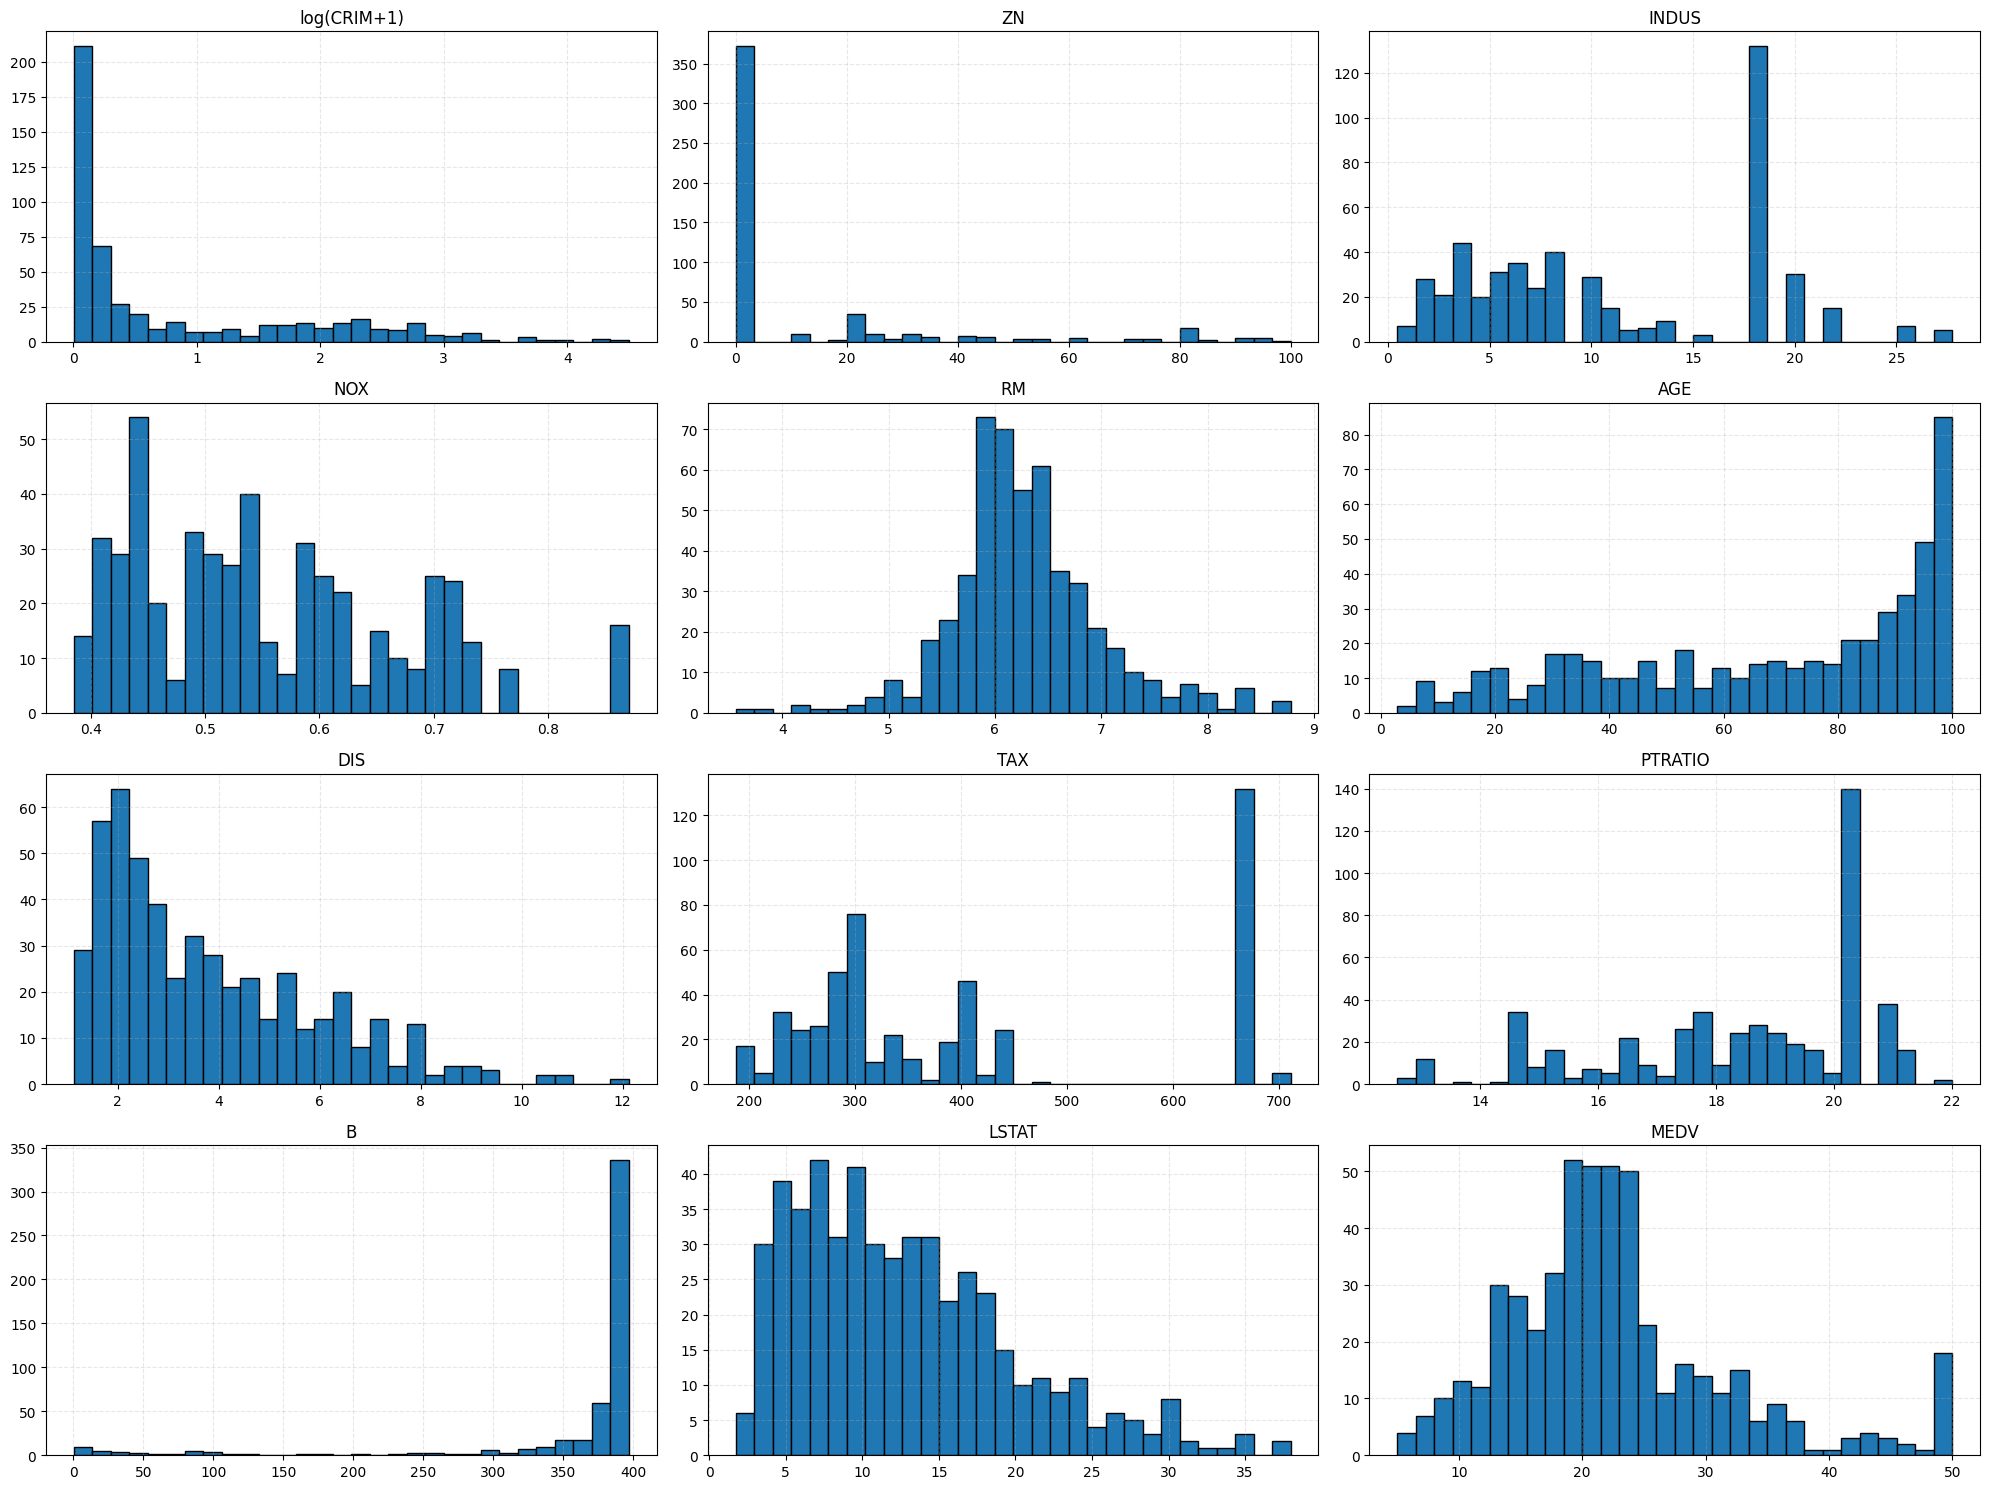

In [71]:
# гистограммы распределения

import numpy as np

plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 3, i)
    if col == 'CRIM':
        plt.hist(np.log1p(data[col]), bins=30, edgecolor='black')
        plt.title(f'log({col}+1)')
    else:
        plt.hist(data[col], bins=30, edgecolor='black')
        plt.title(col)
    plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()